In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.signal as sc
import xarray as xr
np.seterr(divide='ignore')
import numpy.ma as ma

In [26]:
def plot_C_all_Deltas(C_in, c_var, C_sq_1_beta, z, z_i, labels_in, title, plot_dir, case='BOMEX', t='14400', C_type = 'C', set_x_axis=None, IC_label = False):

    clock_time_int = 05.30 + int(t)/(60*60)
    clock_time = str(clock_time_int)+'0L'

    colours = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
               'tab:cyan', 'tab:gray', 'tab:brown', 'tab:olive', 'tab:pink']

    fig, ax = plt.subplots(nrows=1, ncols=1, sharey=False, figsize=(4,6))

    fig.tight_layout(pad=0.5)

    if c_var == 'Cs':
        c_var_label = '$C_{s}$'
    elif c_var == 'Cth':
        c_var_label = '$C_{\\theta}$'
    elif c_var == 'Cth_v':
        c_var_label = '$C_{\\theta_v}$'
    elif c_var == 'Cth_e':
        c_var_label = '$C_{\\theta_e}$'
    elif c_var == 'Cth_L':
        c_var_label = '$C_{\\theta_L}$'
    elif c_var == 'Cqt':
        c_var_label = '$C_{q_t}$'
    elif c_var == 'Cqv':
        c_var_label = '$C_{q_v}$'

    if C_type == 'C':
        if case == 'BOMEX':
            ax.set_xlabel(c_var_label+f' {title}', fontsize=16)

        else:
            ax.set_xlabel(c_var_label+f' {title} at {clock_time}', fontsize=16)


        ax.plot(get_Cs(C_in[0,:]/(C_sq_1_beta[0,:]/C_in[0,:])),
         z/z_i, label='$\\widehat{\\bar{\\Delta}} = 2\\Delta}$ ($\\beta$)')

    else:
        if case == 'BOMEX':
            ax.set_xlabel(c_var_label+'$^2$'+f' {title}', fontsize=16)

        else:
            ax.set_xlabel(c_var_label+'$^2$'+f' {title} at {clock_time}', fontsize=16)


        ax.plot(C_in[0,:]/(C_sq_1_beta[0,:]/C_in[0,:]),
         z/z_i, label='$\\widehat{\\bar{\\Delta}} = 2\\Delta} (\\beta)$')


    for it in range(len(C_in[:,0])):
        if C_type == 'C':
            ax.plot(get_Cs(C_in[it,:]), z/z_i, color=colours[it+1], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])

        else:
            ax.plot(C_in[it,:], z/z_i, color=colours[it+1], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])


    # else:
    #     ax[0].set_xlabel('$C^2_{s}$', fontsize=16)
    #     ax[1].set_xlabel('$C^2_{\\theta}$', fontsize=16)
    #     ax[2].set_xlabel('$C^2_{qt}$', fontsize=16)
    if IC_label == False:
        ax.legend(fontsize=13, loc='upper right')

    else:
        ax.legend(fontsize=13, loc='upper left')


    plt.tight_layout()

    set_left, set_right = ax.set_xlim()

    if set_x_axis is not None:
        set_right = set_x_axis[1]
        set_left = set_x_axis[0]


    print('for all Delta profs, min is = ', set_left, 'max is =', set_right)

    ax.set_xlim(right = set_right, left = set_left)

    ax.set_ylim(bottom=0)
    ax.set_ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i) + "m)", fontsize=16)

    plt.savefig(plot_dir + f'{case}_{t}_{c_var}_{C_type}_{title}_all_Delta_prof_scaled_zn.pdf', bbox_inches='tight')
    plt.savefig(plot_dir + f'{case}_{t}_{c_var}_{C_type}_{title}_all_Delta_prof_scaled_zn.png', bbox_inches='tight')
    plt.show()

    plt.close()

In [27]:
set_labels = ['4$\\Delta$', '8$\\Delta$', '16$\\Delta$', '32$\\Delta$', '64$\\Delta$', '128$\\Delta$']
deltas = ['4D', '8D', '16D', '32D', '64D', '128D']

In [28]:
arm_path_th_L = 'C:/Users/si818415/Documents/code/LES_analysis/data/C_profs_th_L/ARM/'
bomex_path_th_L = 'C:/Users/si818415/Documents/code/LES_analysis/data/C_profs_th_L/BOMEX/'

arm_path_th = 'C:/Users/si818415/Documents/code/LES_analysis/data/C_profs_th/ARM/'
bomex_path_th = 'C:/Users/si818415/Documents/code/LES_analysis/data/C_profs_th/BOMEX/'

arm_path_th_v = 'C:/Users/si818415/Documents/code/LES_analysis/data/th_v/ARM/'
bomex_path_th_v = 'C:/Users/si818415/Documents/code/LES_analysis/data/th_v/BOMEX/'

# arm_path_th_e = 'C:/Users/si818415/Documents/code/LES_analysis/data/th_e/ARM/'
# bomex_path_th_e = 'C:/Users/si818415/Documents/code/LES_analysis/data/th_e/BOMEX/'


plot_dir_BOMEX = 'C:/Users/si818415/Documents/plots/C_profs_ALL/BOMEX/C_profs/'
plot_dir_ARM = 'C:/Users/si818415/Documents/plots/C_profs_ALL/ARM/C_profs/'
plot_dir_all = 'C:/Users/si818415/Documents/plots/C_profs_ALL/C_profs/'

path='C:/Users/si818415/Documents/code/LES_analysis/data/'

os.makedirs(plot_dir_BOMEX, exist_ok = True)
os.makedirs(plot_dir_ARM, exist_ok = True)
os.makedirs(plot_dir_all, exist_ok = True)

In [29]:

dx_BOMEX=20
z_BOMEX = np.arange(0, 3020, 20)
z_i_BOMEX = 430 #1120


dx_ARM=25
z_ARM = np.arange(0, 4410, 10)
z_i_ARM = [795, 955, 1095, 1255]

In [30]:
Cs_sq_BOMEX_0 = np.load(bomex_path_th_L+f'C_sq_cond_14400_0.npy')[0,...]
Cs_sq_BOMEX_1 = np.load(bomex_path_th_L+f'C_sq_cond_14400_1.npy')[0,...]

Cs_sq_ARM_18000_0 = np.load(arm_path_th_L+f'C_sq_cond_18000_0.npy')[0,...]
Cs_sq_ARM_25200_0 = np.load(arm_path_th_L+f'C_sq_cond_25200_0.npy')[0,...]
Cs_sq_ARM_32400_0 = np.load(arm_path_th_L+f'C_sq_cond_32400_0.npy')[0,...]
Cs_sq_ARM_39600_0 = np.load(arm_path_th_L+f'C_sq_cond_39600_0.npy')[0,...]

Cs_sq_ARM_18000_1 = np.load(arm_path_th_L+f'C_sq_cond_18000_1.npy')[0,...]
Cs_sq_ARM_25200_1 = np.load(arm_path_th_L+f'C_sq_cond_25200_1.npy')[0,...]
Cs_sq_ARM_32400_1 = np.load(arm_path_th_L+f'C_sq_cond_32400_1.npy')[0,...]
Cs_sq_ARM_39600_1 = np.load(arm_path_th_L+f'C_sq_cond_39600_1.npy')[0,...]


Cs_sq_ARM_0 = [Cs_sq_ARM_18000_0, Cs_sq_ARM_25200_0, Cs_sq_ARM_32400_0, Cs_sq_ARM_39600_0]
Cs_sq_ARM_1 = [Cs_sq_ARM_18000_1, Cs_sq_ARM_25200_1, Cs_sq_ARM_32400_1, Cs_sq_ARM_39600_1]

Cs_sq_ARM_0 = np.reshape(Cs_sq_ARM_0, ( 4, len(Cs_sq_ARM_18000_0[:, 0,0]), len(Cs_sq_ARM_18000_0[0,:,0]), len(Cs_sq_ARM_18000_0[0,0,:])  ) )
Cs_sq_ARM_1 = np.reshape(Cs_sq_ARM_1, ( 4, len(Cs_sq_ARM_18000_1[:, 0,0]), len(Cs_sq_ARM_18000_1[0,:,0]), len(Cs_sq_ARM_18000_1[0,0,:])  ) )



Cth_L_sq_BOMEX_0 = np.load(bomex_path_th_L+f'C_sq_cond_14400_0.npy')[1,...]
Cth_L_sq_BOMEX_1 = np.load(bomex_path_th_L+f'C_sq_cond_14400_1.npy')[1,...]

Cth_L_sq_ARM_18000_0 = np.load(arm_path_th_L+f'C_sq_cond_18000_0.npy')[1,...]
Cth_L_sq_ARM_25200_0 = np.load(arm_path_th_L+f'C_sq_cond_25200_0.npy')[1,...]
Cth_L_sq_ARM_32400_0 = np.load(arm_path_th_L+f'C_sq_cond_32400_0.npy')[1,...]
Cth_L_sq_ARM_39600_0 = np.load(arm_path_th_L+f'C_sq_cond_39600_0.npy')[1,...]

Cth_L_sq_ARM_18000_1 = np.load(arm_path_th_L+f'C_sq_cond_18000_1.npy')[1,...]
Cth_L_sq_ARM_25200_1 = np.load(arm_path_th_L+f'C_sq_cond_25200_1.npy')[1,...]
Cth_L_sq_ARM_32400_1 = np.load(arm_path_th_L+f'C_sq_cond_32400_1.npy')[1,...]
Cth_L_sq_ARM_39600_1 = np.load(arm_path_th_L+f'C_sq_cond_39600_1.npy')[1,...]


Cth_L_sq_ARM_0 = [Cth_L_sq_ARM_18000_0, Cth_L_sq_ARM_25200_0, Cth_L_sq_ARM_32400_0, Cth_L_sq_ARM_39600_0]
Cth_L_sq_ARM_1 = [Cth_L_sq_ARM_18000_1, Cth_L_sq_ARM_25200_1, Cth_L_sq_ARM_32400_1, Cth_L_sq_ARM_39600_1]

Cth_L_sq_ARM_0 = np.reshape(Cth_L_sq_ARM_0, ( 4, len(Cs_sq_ARM_18000_0[:, 0,0]), len(Cs_sq_ARM_18000_0[0,:,0]), len(Cs_sq_ARM_18000_0[0,0,:])  ) )
Cth_L_sq_ARM_1 = np.reshape(Cth_L_sq_ARM_1, ( 4, len(Cs_sq_ARM_18000_1[:, 0,0]), len(Cs_sq_ARM_18000_1[0,:,0]), len(Cs_sq_ARM_18000_1[0,0,:])  ) )



Cth_sq_BOMEX_0 = np.load(bomex_path_th+f'C_sq_cond_14400_0.npy')[1,...]
Cth_sq_BOMEX_1 = np.load(bomex_path_th+f'C_sq_cond_14400_1.npy')[1,...]

Cth_sq_ARM_18000_0 = np.load(arm_path_th+f'C_sq_cond_18000_0.npy')[1,...]
Cth_sq_ARM_25200_0 = np.load(arm_path_th+f'C_sq_cond_25200_0.npy')[1,...]
Cth_sq_ARM_32400_0 = np.load(arm_path_th+f'C_sq_cond_32400_0.npy')[1,...]
Cth_sq_ARM_39600_0 = np.load(arm_path_th+f'C_sq_cond_39600_0.npy')[1,...]

Cth_sq_ARM_18000_1 = np.load(arm_path_th+f'C_sq_cond_18000_1.npy')[1,...]
Cth_sq_ARM_25200_1 = np.load(arm_path_th+f'C_sq_cond_25200_1.npy')[1,...]
Cth_sq_ARM_32400_1 = np.load(arm_path_th+f'C_sq_cond_32400_1.npy')[1,...]
Cth_sq_ARM_39600_1 = np.load(arm_path_th+f'C_sq_cond_39600_1.npy')[1,...]


Cth_sq_ARM_0 = [Cth_sq_ARM_18000_0, Cth_sq_ARM_25200_0, Cth_sq_ARM_32400_0, Cth_sq_ARM_39600_0]
Cth_sq_ARM_1 = [Cth_sq_ARM_18000_1, Cth_sq_ARM_25200_1, Cth_sq_ARM_32400_1, Cth_sq_ARM_39600_1]

Cth_sq_ARM_0 = np.reshape(Cth_sq_ARM_0, ( 4, len(Cs_sq_ARM_18000_0[:, 0,0]), len(Cs_sq_ARM_18000_0[0,:,0]), len(Cs_sq_ARM_18000_0[0,0,:])  ) )
Cth_sq_ARM_1 = np.reshape(Cth_sq_ARM_1, ( 4, len(Cs_sq_ARM_18000_1[:, 0,0]), len(Cs_sq_ARM_18000_1[0,:,0]), len(Cs_sq_ARM_18000_1[0,0,:])  ) )





Cth_v_sq_BOMEX_0 = np.load(bomex_path_th_v+f'C_sq_cond_14400_0.npy')[0,...]
Cth_v_sq_BOMEX_1 = np.load(bomex_path_th_v+f'C_sq_cond_14400_1.npy')[0,...]

# Cth_v_sq_ARM_18000_0 = np.load(arm_path_th_v+f'C_sq_cond_18000_0.npy')[0,...]
# Cth_v_sq_ARM_25200_0 = np.load(arm_path_th_v+f'C_sq_cond_25200_0.npy')[0,...]
# Cth_v_sq_ARM_32400_0 = np.load(arm_path_th_v+f'C_sq_cond_32400_0.npy')[0,...]
# Cth_v_sq_ARM_39600_0 = np.load(arm_path_th_v+f'C_sq_cond_39600_0.npy')[0,...]
#
# Cth_v_sq_ARM_18000_1 = np.load(arm_path_th_v+f'C_sq_cond_18000_1.npy')[0,...]
# Cth_v_sq_ARM_25200_1 = np.load(arm_path_th_v+f'C_sq_cond_25200_1.npy')[0,...]
# Cth_v_sq_ARM_32400_1 = np.load(arm_path_th_v+f'C_sq_cond_32400_1.npy')[0,...]
# Cth_v_sq_ARM_39600_1 = np.load(arm_path_th_v+f'C_sq_cond_39600_1.npy')[0,...]




#
# Cth_e_sq_BOMEX_0 = np.load(bomex_path_th_e+f'C_sq_cond_14400_0.npy')[0,...]
# Cth_e_sq_BOMEX_1 = np.load(bomex_path_th_e+f'C_sq_cond_14400_1.npy')[0,...]
#
# Cth_e_sq_ARM_18000_0 = np.load(arm_path_th_e+f'C_sq_cond_18000_0.npy')[0,...]
# Cth_e_sq_ARM_25200_0 = np.load(arm_path_th_e+f'C_sq_cond_25200_0.npy')[0,...]
# Cth_e_sq_ARM_32400_0 = np.load(arm_path_th_e+f'C_sq_cond_32400_0.npy')[0,...]
# Cth_e_sq_ARM_39600_0 = np.load(arm_path_th_e+f'C_sq_cond_39600_0.npy')[0,...]
#
# Cth_e_sq_ARM_18000_1 = np.load(arm_path_th_e+f'C_sq_cond_18000_1.npy')[0,...]
# Cth_e_sq_ARM_25200_1 = np.load(arm_path_th_e+f'C_sq_cond_25200_1.npy')[0,...]
# Cth_e_sq_ARM_32400_1 = np.load(arm_path_th_e+f'C_sq_cond_32400_1.npy')[0,...]
# Cth_e_sq_ARM_39600_1 = np.load(arm_path_th_e+f'C_sq_cond_39600_1.npy')[0,...]



Cqt_sq_BOMEX_0 = np.load(bomex_path_th_L+f'C_sq_cond_14400_0.npy')[2,...]
Cqt_sq_BOMEX_1 = np.load(bomex_path_th_L+f'C_sq_cond_14400_1.npy')[2,...]

Cqt_sq_ARM_18000_0 = np.load(arm_path_th_L+f'C_sq_cond_18000_0.npy')[2,...]
Cqt_sq_ARM_25200_0 = np.load(arm_path_th_L+f'C_sq_cond_25200_0.npy')[2,...]
Cqt_sq_ARM_32400_0 = np.load(arm_path_th_L+f'C_sq_cond_32400_0.npy')[2,...]
Cqt_sq_ARM_39600_0 = np.load(arm_path_th_L+f'C_sq_cond_39600_0.npy')[2,...]

Cqt_sq_ARM_18000_1 = np.load(arm_path_th_L+f'C_sq_cond_18000_1.npy')[2,...]
Cqt_sq_ARM_25200_1 = np.load(arm_path_th_L+f'C_sq_cond_25200_1.npy')[2,...]
Cqt_sq_ARM_32400_1 = np.load(arm_path_th_L+f'C_sq_cond_32400_1.npy')[2,...]
Cqt_sq_ARM_39600_1 = np.load(arm_path_th_L+f'C_sq_cond_39600_1.npy')[2,...]


Cqt_sq_ARM_0 = [Cqt_sq_ARM_18000_0, Cqt_sq_ARM_25200_0, Cqt_sq_ARM_32400_0, Cqt_sq_ARM_39600_0]
Cqt_sq_ARM_1 = [Cqt_sq_ARM_18000_1, Cqt_sq_ARM_25200_1, Cqt_sq_ARM_32400_1, Cqt_sq_ARM_39600_1]

Cqt_sq_ARM_0 = np.reshape(Cqt_sq_ARM_0, ( 4, len(Cs_sq_ARM_18000_0[:, 0,0]), len(Cs_sq_ARM_18000_0[0,:,0]), len(Cs_sq_ARM_18000_0[0,0,:])  ) )
Cqt_sq_ARM_1 = np.reshape(Cqt_sq_ARM_1, ( 4, len(Cs_sq_ARM_18000_1[:, 0,0]), len(Cs_sq_ARM_18000_1[0,:,0]), len(Cs_sq_ARM_18000_1[0,0,:])  ) )




# Cqv_sq_BOMEX_0 = np.load(bomex_path_th_e+f'C_sq_cond_14400_0.npy')[1,...]
# Cqv_sq_BOMEX_1 = np.load(bomex_path_th_e+f'C_sq_cond_14400_1.npy')[1,...]
#
# Cqv_sq_ARM_18000_0 = np.load(arm_path_th_e+f'C_sq_cond_18000_0.npy')[1,...]
# Cqv_sq_ARM_25200_0 = np.load(arm_path_th_e+f'C_sq_cond_25200_0.npy')[1,...]
# Cqv_sq_ARM_32400_0 = np.load(arm_path_th_e+f'C_sq_cond_32400_0.npy')[1,...]
# Cqv_sq_ARM_39600_0 = np.load(arm_path_th_e+f'C_sq_cond_39600_0.npy')[1,...]
#
# Cqv_sq_ARM_18000_1 = np.load(arm_path_th_e+f'C_sq_cond_18000_1.npy')[1,...]
# Cqv_sq_ARM_25200_1 = np.load(arm_path_th_e+f'C_sq_cond_25200_1.npy')[1,...]
# Cqv_sq_ARM_32400_1 = np.load(arm_path_th_e+f'C_sq_cond_32400_1.npy')[1,...]
# Cqv_sq_ARM_39600_1 = np.load(arm_path_th_e+f'C_sq_cond_39600_1.npy')[1,...]


In [31]:
print(np.shape(Cs_sq_ARM_1))

(4, 5, 1, 441)


In [32]:
def get_Cs(Cs_sq):
    """ calculates C_s from C_s^2 by setting neg values to zero
    and sq rooting"""

    Cs_sq_copy = Cs_sq.copy()
    Cs_sq_copy[Cs_sq < 0] = 0
    Cs = np.sqrt(Cs_sq_copy)

    return Cs

In [33]:
partit = ['dom_av', 'NC', 'IC', 'CU', 'CC']

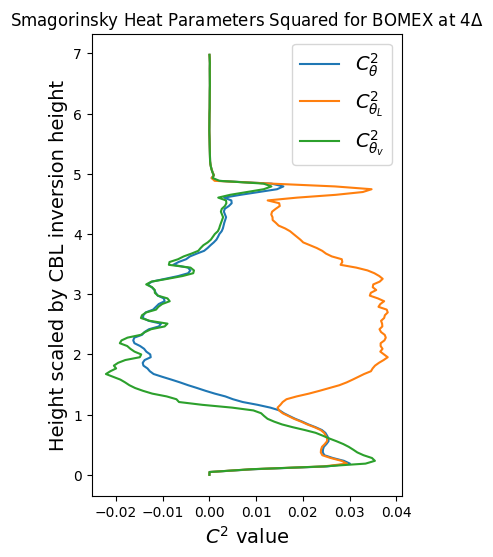

In [14]:
p = 0
d=0
case='BOMEX'

plt.figure(figsize=(4,6))
plt.title(f'Smagorinsky Heat Parameters Squared for {case}'+' at $4\\Delta$')
plt.plot(Cth_sq_BOMEX_0[p,d,:], z_BOMEX/z_i_BOMEX, label='$C_{\\theta}^2$')
plt.plot(Cth_L_sq_BOMEX_0[p,d,:], z_BOMEX/z_i_BOMEX, label='$C_{\\theta_L}^2$')
plt.plot(Cth_v_sq_BOMEX_0[p,d,:], z_BOMEX/z_i_BOMEX, label='$C_{\\theta_v}^2$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C^2$ value', size=14)
#plt.xlim(right=0.3)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig(f'{plot_dir_BOMEX}{case}_C_ths_sq_{partit[p]}_profs_{deltas[d]}.pdf', bbox_inches='tight')
plt.show()

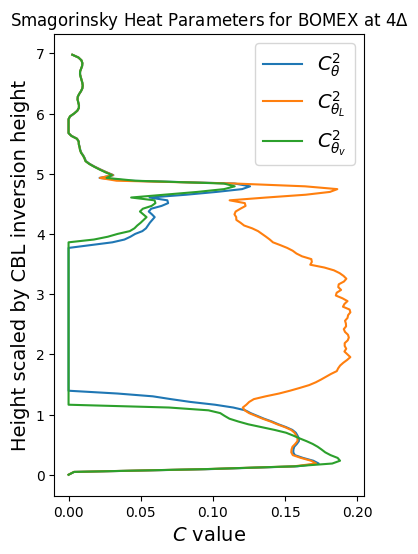

In [15]:
p = 0
d=0
case='BOMEX'

plt.figure(figsize=(4,6))
plt.title(f'Smagorinsky Heat Parameters for {case}'+' at $4\\Delta$')
plt.plot(get_Cs(Cth_sq_BOMEX_0[p,d,:]), z_BOMEX/z_i_BOMEX, label='$C_{\\theta}^2$')
plt.plot(get_Cs(Cth_L_sq_BOMEX_0[p,d,:]), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_L}^2$')
plt.plot(get_Cs(Cth_v_sq_BOMEX_0[p,d,:]), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_v}^2$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C$ value', size=14)
#plt.xlim(right=0.3)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig(f'{plot_dir_BOMEX}{case}_C_ths_{partit[p]}_profs_{deltas[d]}.pdf', bbox_inches='tight')
plt.show()

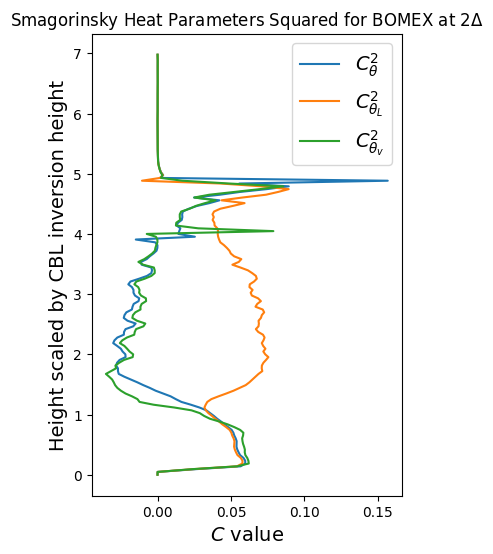

In [27]:
p = 0
d=0
case='BOMEX'

plt.figure(figsize=(4,6))
plt.title(f'Smagorinsky Heat Parameters Squared for {case}'+' at $2\\Delta$')
plt.plot(Cth_sq_BOMEX_0[p,d,:]/(Cth_sq_BOMEX_1[p,d,:]/Cth_sq_BOMEX_0[p,d,:]), z_BOMEX/z_i_BOMEX, label='$C_{\\theta}^2$')
plt.plot(Cth_L_sq_BOMEX_0[p,d,:]/(Cth_L_sq_BOMEX_1[p,d,:]/Cth_L_sq_BOMEX_0[p,d,:]), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_L}^2$')
plt.plot(Cth_v_sq_BOMEX_0[p,d,:]/(Cth_v_sq_BOMEX_1[p,d,:]/Cth_v_sq_BOMEX_0[p,d,:]), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_v}^2$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C$ value', size=14)
#plt.xlim(right=0.3)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig(f'{plot_dir_BOMEX}{case}_C_ths_sq_beta_{partit[p]}_profs_{deltas[d]}.pdf', bbox_inches='tight')

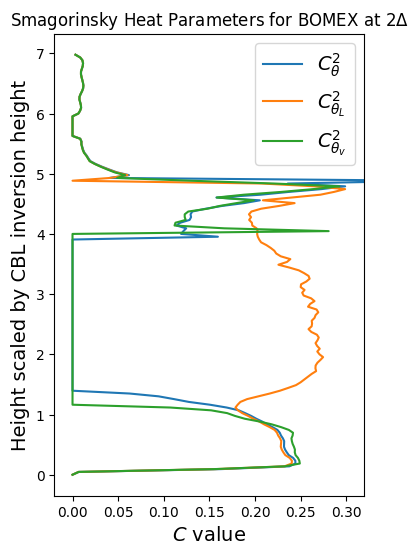

In [26]:
p = 0
d=0
case='BOMEX'

plt.figure(figsize=(4,6))
plt.title(f'Smagorinsky Heat Parameters for {case}'+' at $2\\Delta$')
plt.plot(get_Cs(Cth_sq_BOMEX_0[p,d,:]/(Cth_sq_BOMEX_1[p,d,:]/Cth_sq_BOMEX_0[p,d,:])), z_BOMEX/z_i_BOMEX, label='$C_{\\theta}^2$')
plt.plot(get_Cs(Cth_L_sq_BOMEX_0[p,d,:]/(Cth_L_sq_BOMEX_1[p,d,:]/Cth_L_sq_BOMEX_0[p,d,:])), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_L}^2$')
plt.plot(get_Cs(Cth_v_sq_BOMEX_0[p,d,:]/(Cth_v_sq_BOMEX_1[p,d,:]/Cth_v_sq_BOMEX_0[p,d,:])), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_v}^2$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C$ value', size=14)
plt.xlim(right=0.32)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig(f'{plot_dir_BOMEX}{case}_C_ths_beta_{partit[p]}_profs_{deltas[d]}.pdf', bbox_inches='tight')

for all Delta profs, min is =  -0.01 max is = 0.26


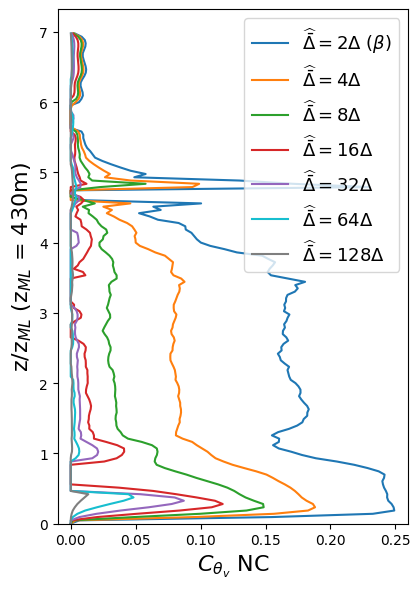

In [62]:
p = 1
partition = ['domain average', 'NC', 'IC', 'CU', 'CC']

plot_C_all_Deltas(Cth_v_sq_BOMEX_0[p,...], 'Cth_v', Cth_v_sq_BOMEX_1[p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, partition[p], plot_dir_BOMEX,  C_type = 'C', set_x_axis=[-0.01, 0.26])#, IC_label = True)


In [8]:
ARM_times = ['18000', '25200', '32400', '39600']

for condit profs, min is =  -0.028927494985620562 max is = 0.25856238218346356
for condit profs, min is =  -0.024462352934897482 max is = 0.29173093229097
for condit profs, min is =  -0.02036549676876969 max is = 0.18454316389972147
for condit profs, min is =  -0.015433238499229235 max is = 0.14005294829439258
for condit profs, min is =  -0.01319407802866164 max is = 0.11701663287231379
for condit profs, min is =  -0.008133285064799187 max is = 0.06453198856473062


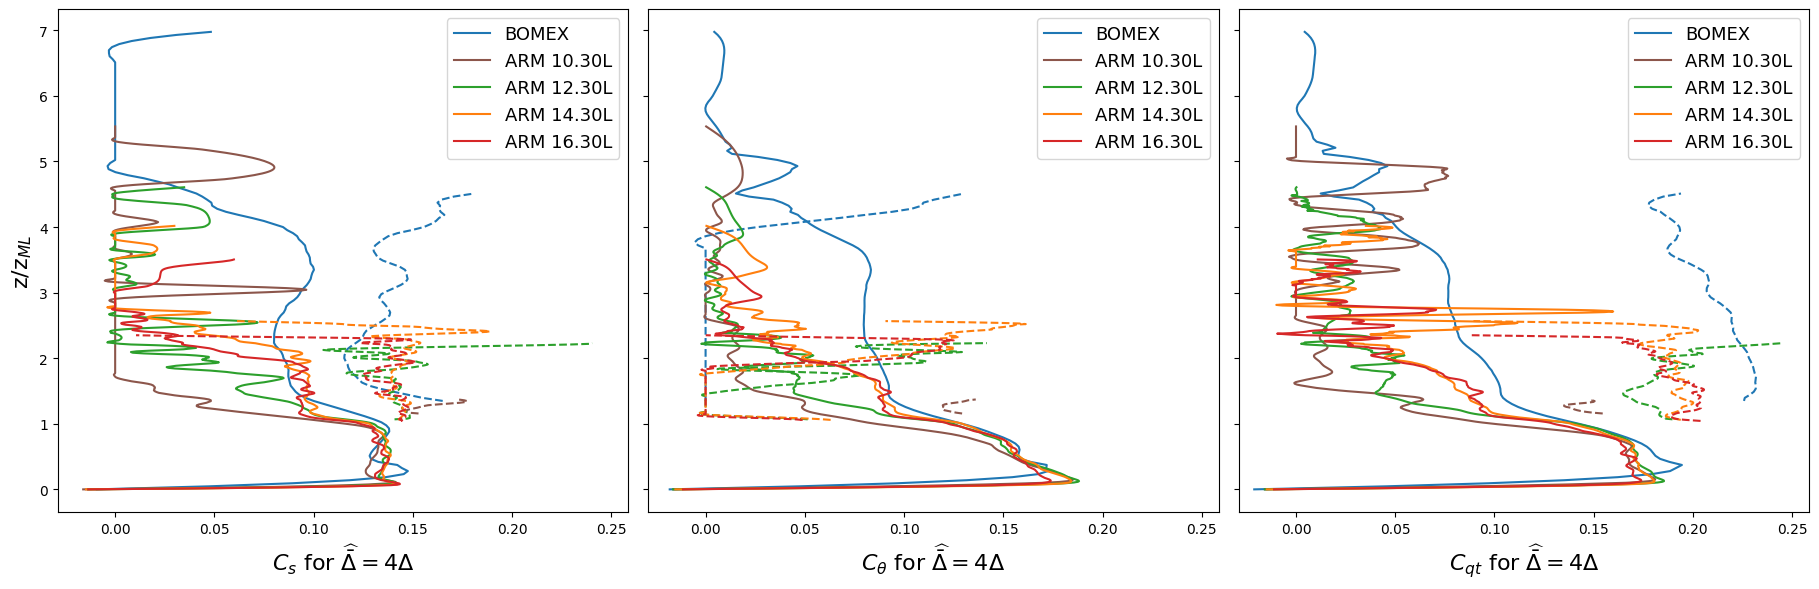

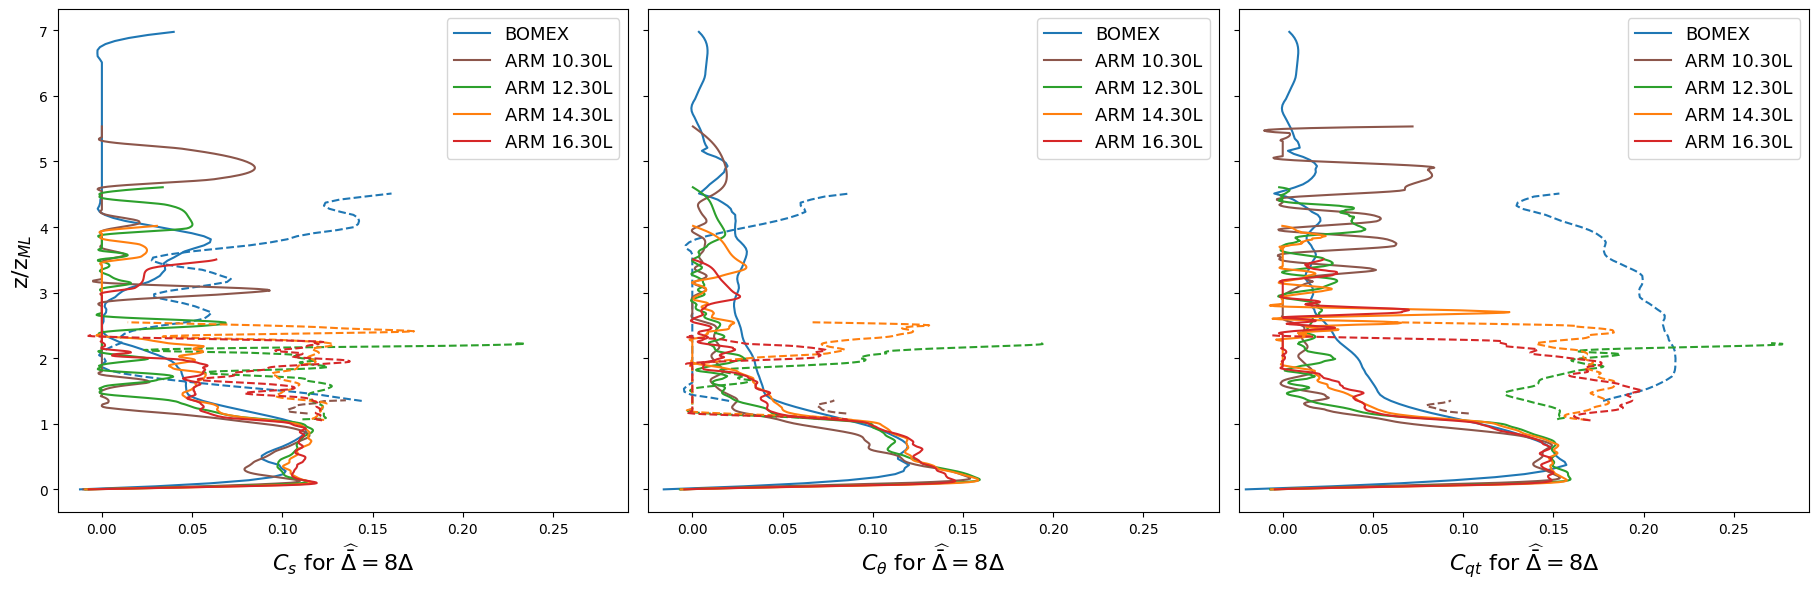

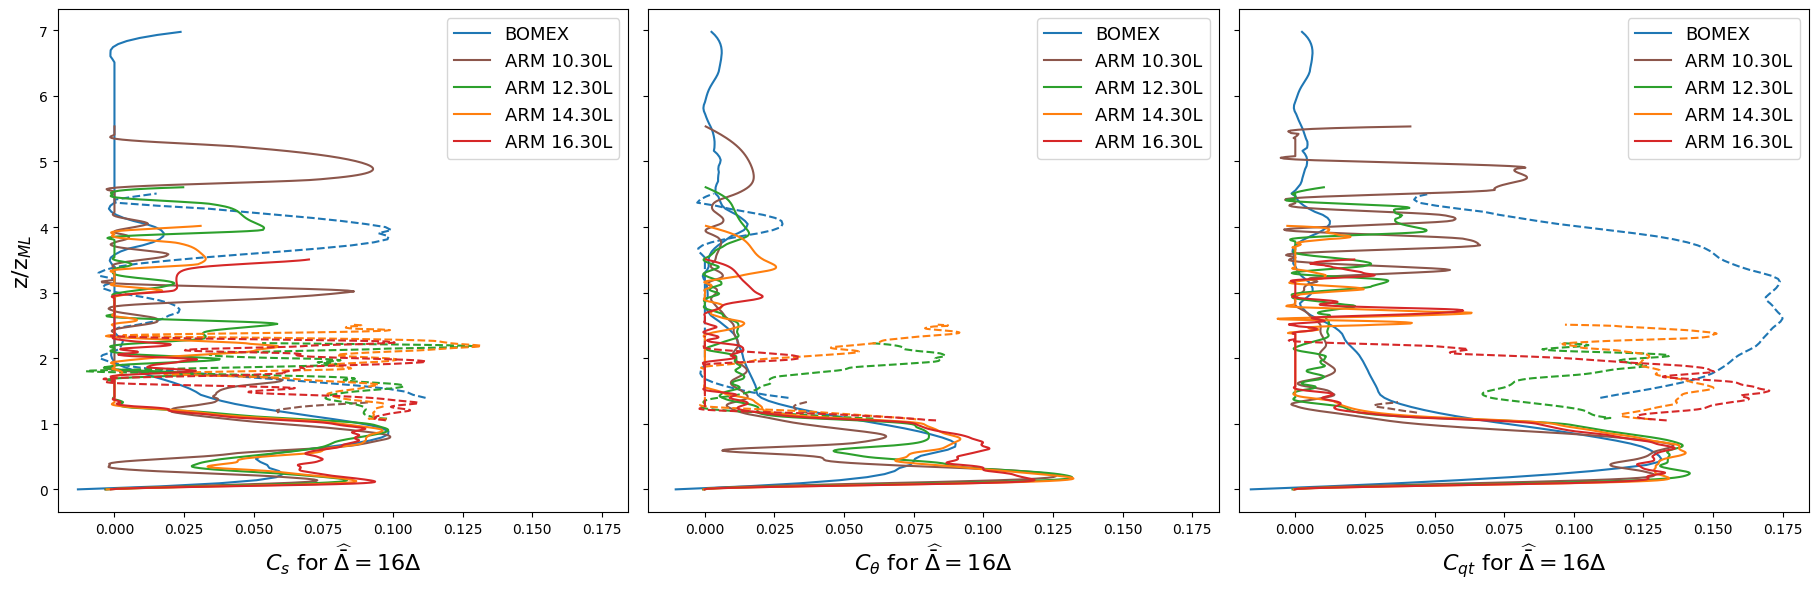

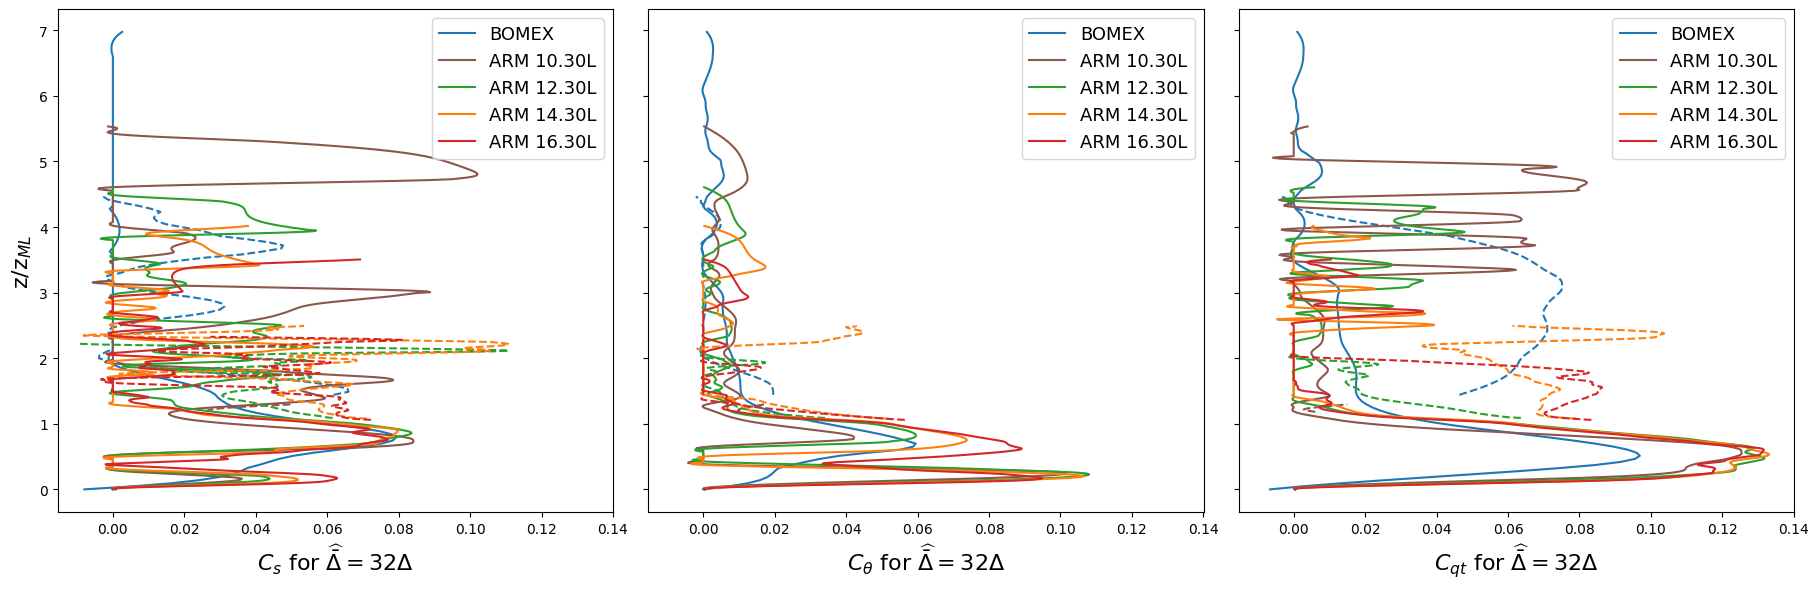

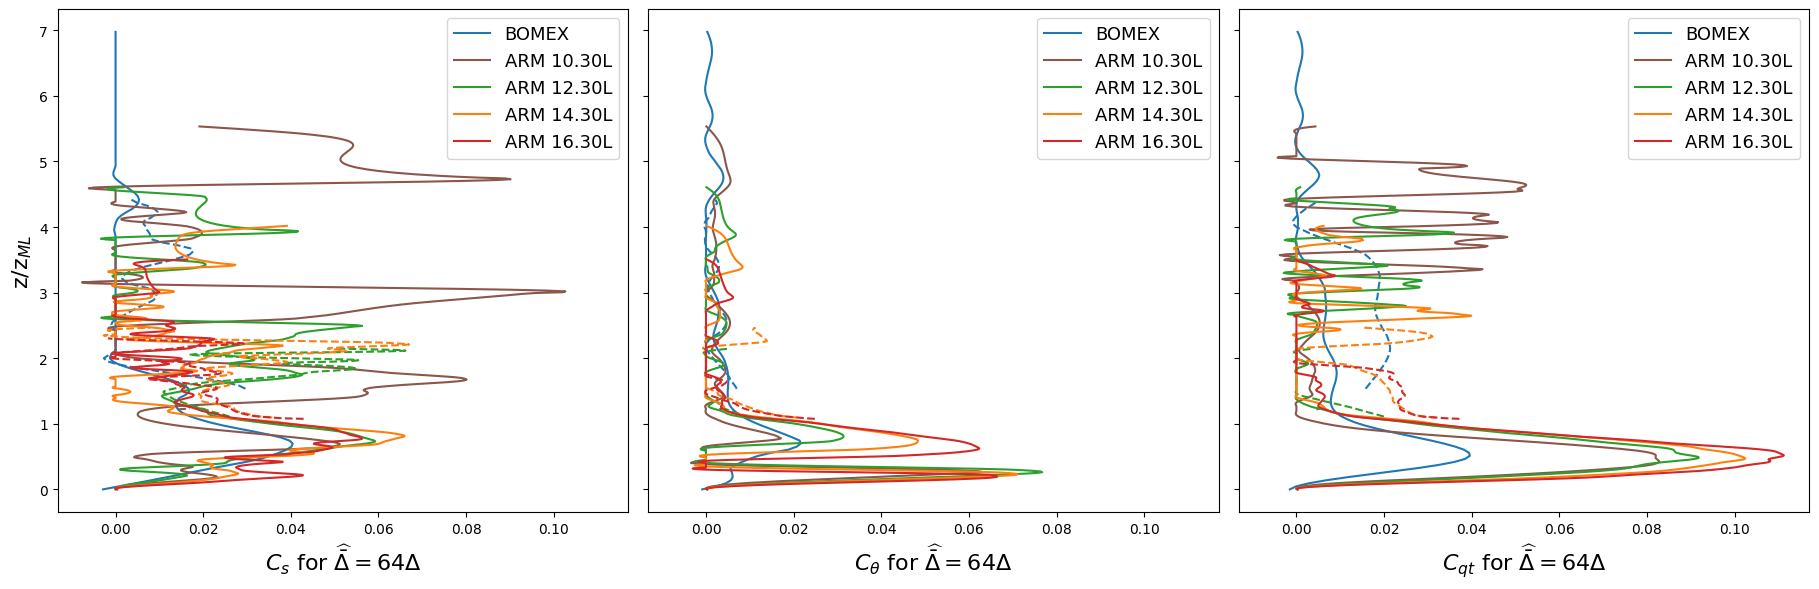

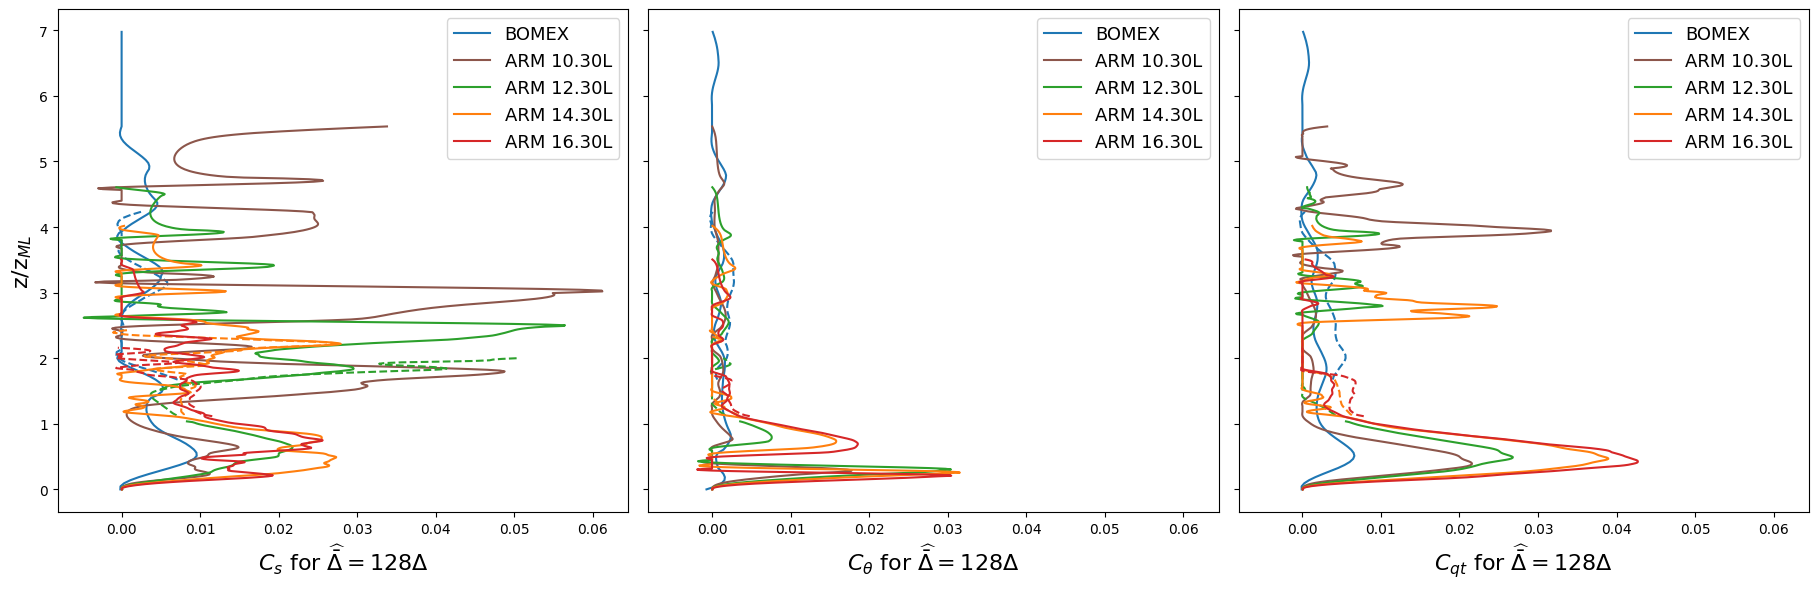

In [40]:
def height_C_rel(alpha_star, C_nc_in, h, z, gamma=20):

    vert = np.ones_like(z)

    C_nc = C_nc_in*vert
    C_prof = ((h/z)**gamma)*(1-(z/h))**2
    alpha = alpha_star - C_nc

    C_new = alpha*(1/( (1/C_prof) + 1)) + C_nc

    return C_new

z_rel = np.arange(0,3000,10)
zi = 1000


Cs_rel = height_C_rel(alpha_star=0.145, C_nc_in=0.1, h=1.25*zi, z=z_rel, gamma=20)
Cth_rel = height_C_rel(alpha_star=0.165, C_nc_in=0.1, h=1.2*zi, z=z_rel, gamma=10)
Cqt_rel = height_C_rel(alpha_star=0.185, C_nc_in=0.1, h=1.2*zi, z=z_rel, gamma=16)



def clock(time_in):
    clock_time_int = 05.30 + int(time_in)/(60*60)
    clock_time = str(clock_time_int)+'0L'
    return clock_time

colours = [ 'tab:blue', 'tab:brown', 'tab:green', 'tab:orange', 'tab:red', 'tab:purple',
             'tab:olive', 'tab:cyan', 'tab:gray', 'tab:pink']

 # C shape is [conditionals, Delta, z]


for d, Delta in enumerate(deltas):


    fig, ax = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(18,6))
    fig.tight_layout(pad=1)

    ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_BOMEX_0[1,d,:]), 15, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')
    ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_BOMEX_0[1,d,:]), 15, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')
    ax[2].plot(sc.savgol_filter( get_Cs(Cqt_sq_BOMEX_0[1,d,:]), 15, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')
    # if d == 1:
    #     ax[0].plot(sc.savgol_filter( Cs_dry, 5, 3), z_s_dry/dry_zi_m, color=colours[1], label=f'dry CBL')
    #     ax[1].plot(sc.savgol_filter( Cth_dry, 5, 3), z_th_dry/dry_zi_m, color=colours[1], label=f'dry CBL')
    #     #ax[1].plot(Cth_dry, z_th_dry/dry_zi_m, color=colours[1], label=f'dry CBL')

    ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_BOMEX_0[2,d,:]), 15, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed') #, label=f'BOMEX cloud')
    ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_BOMEX_0[2,d,:]), 15, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed') #, label=f'BOMEX cloud')
    ax[2].plot(sc.savgol_filter( get_Cs(Cqt_sq_BOMEX_0[2,d,:]), 15, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed') #, label=f'BOMEX cloud')


    for nt, time in enumerate(ARM_times):

        ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_ARM_0[nt,1,d,:]), 15, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')
        ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_ARM_0[nt,1,d,:]), 15, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')
        ax[2].plot(sc.savgol_filter( get_Cs(Cqt_sq_ARM_0[nt,1,d,:]), 15, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')

        ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_ARM_0[nt,2,d,:]), 15, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')
        ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_ARM_0[nt,2,d,:]), 15, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')
        ax[2].plot(sc.savgol_filter( get_Cs(Cqt_sq_ARM_0[nt,2,d,:]), 15, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')

    # if d == 1:
    #
    #     ax[0].plot(Cs_rel, z_rel/zi, color='k', label=f'param')
    #     ax[1].plot(Cth_rel, z_rel/zi, color='k', label=f'param')
    #     ax[2].plot(Cqt_rel, z_rel/zi, color='k', label=f'param')

    ax[0].set_xlabel('$C_{s}$ for $\\widehat{\\bar{\\Delta}} = $'+set_labels[d], fontsize=16)
    ax[1].set_xlabel('$C_{\\theta}$ for $\\widehat{\\bar{\\Delta}} = $' + set_labels[d], fontsize=16)
    ax[2].set_xlabel('$C_{qt}$ for $\\widehat{\\bar{\\Delta}} = $' + set_labels[d], fontsize=16)

    ax[0].legend(fontsize=13, loc='upper right')
    ax[1].legend(fontsize=13, loc='upper right')
    ax[2].legend(fontsize=13, loc='upper right')

    left0, right0 = ax[0].set_xlim()
    left1, right1 = ax[1].set_xlim()
    left2, right2 = ax[2].set_xlim()

    set_right = max(right0, right1, right2)
    set_left = left0
    print('for condit profs, min is = ', set_left, 'max is =', set_right)

    ax[0].set_xlim(right=set_right, left=set_left)
    ax[1].set_xlim(right=set_right, left=set_left)
    ax[2].set_xlim(right=set_right, left=set_left)

    plt.tight_layout()


    ax[0].set_ylabel("z/z$_{ML}$", fontsize=16)
    # ax[1].set_ylabel("z/z$_{ML}$ (z$_{ML}$", fontsize=16)
    # ax[2].set_ylabel("z/z$_{ML}$ (z$_{ML}$", fontsize=16)

    plt.savefig(plot_dir_all + f'all_cases_C_env_and_clouds_prof_D={Delta}_scaled_zi.pdf',
                bbox_inches='tight')
    plt.savefig(plot_dir_all + f'all_cases_C_env_and_clouds_prof_D={Delta}_scaled_zi.png',
                bbox_inches='tight')

for all Delta profs, min is =  -0.01 max is = 0.3


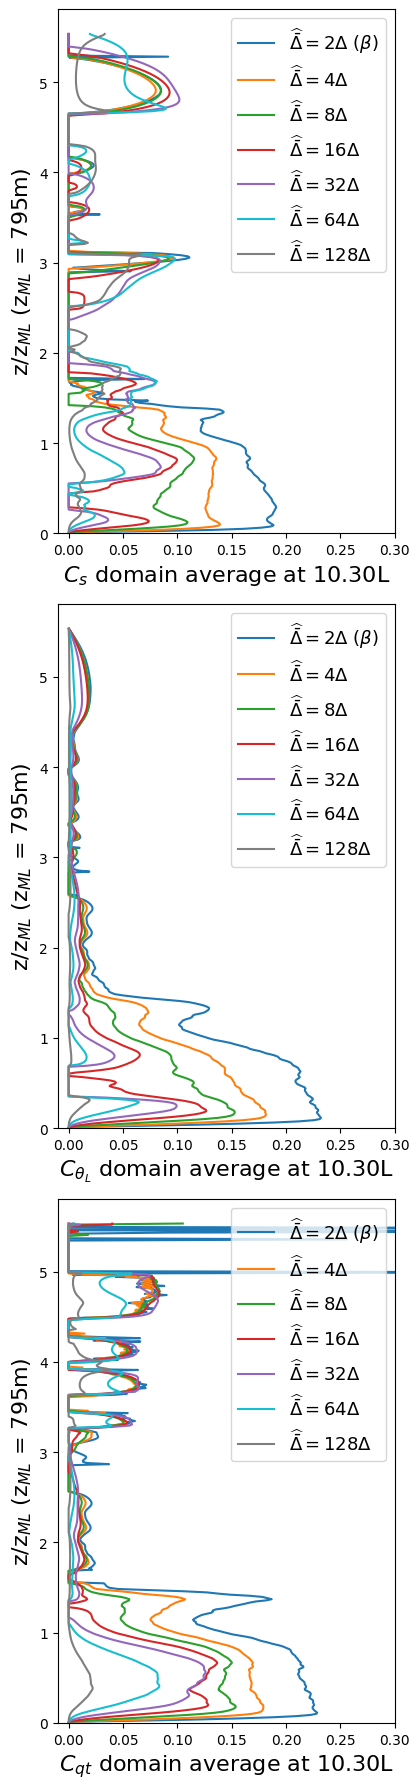

In [95]:
p = 0
time_stamp = 0

plot_C_all_Deltas(C_sq_ARM_18000_0[0,p,...], C_sq_ARM_18000_0[1,p,...], C_sq_ARM_18000_0[2,p,...], C_sq_ARM_18000_1[:,p,:,:],
                  z_ARM, z_i_ARM[time_stamp], set_labels, 'domain average', plot_dir_ARM, case='ARM',
                  t=ARM_times[time_stamp], C_type = 'C', set_x_axis=[-0.01, 0.3], IC_label = False)

for all Delta profs, min is =  -0.08012537741404915 max is = 0.17287125349406982


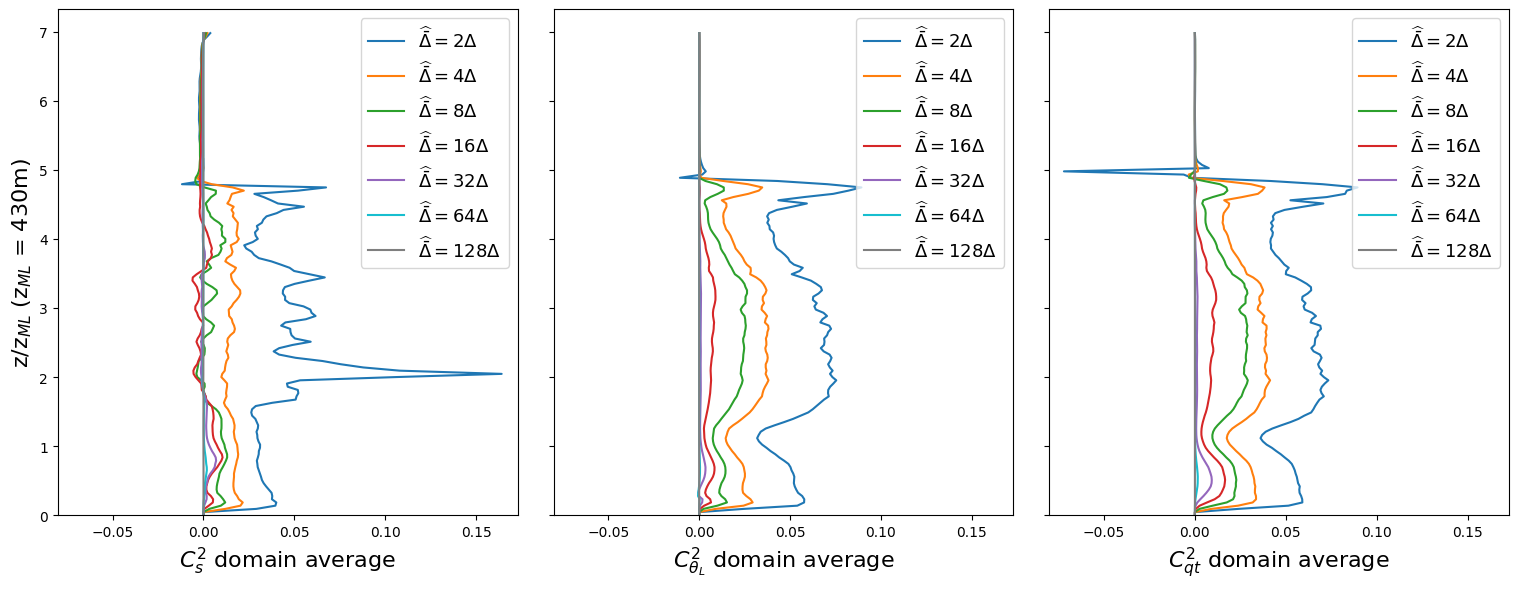

In [96]:
p = 0

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'domain average', plot_dir_BOMEX, C_type = 'C_sq', IC_label=False)

for all Delta profs, min is =  -0.01215577129540171 max is = 0.2552711972034359


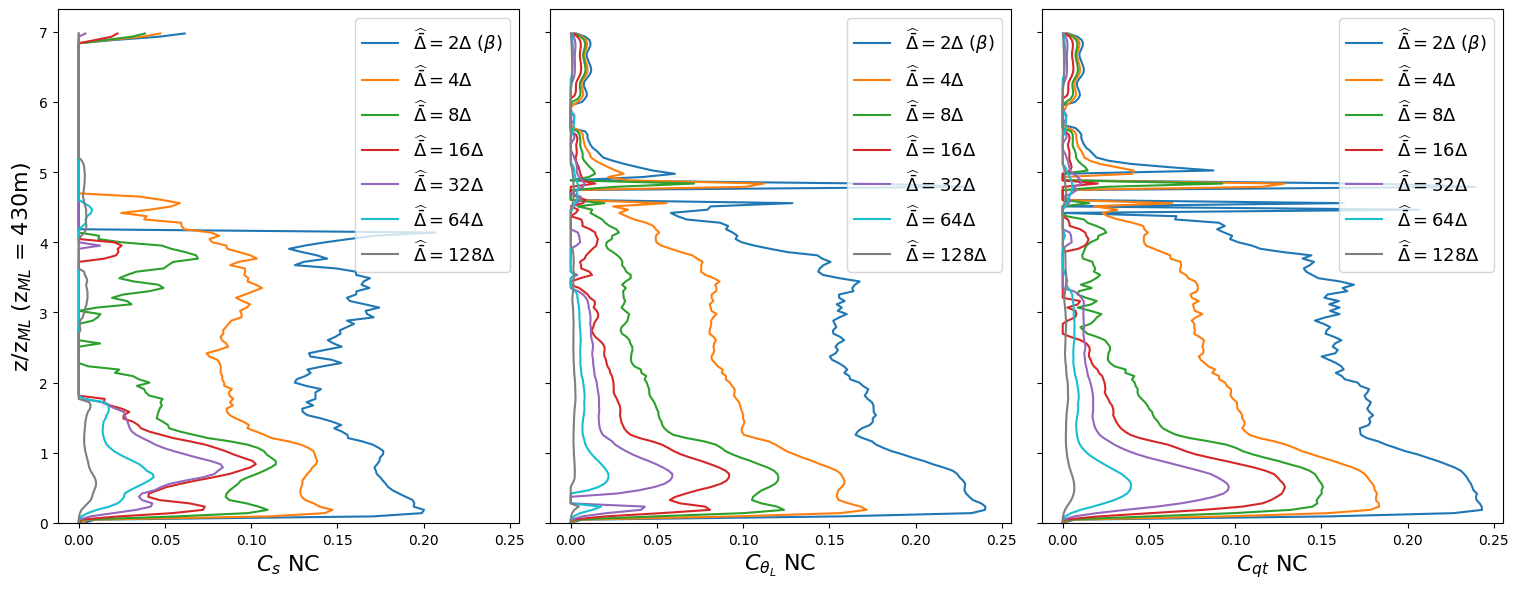

In [97]:
p = 1

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'NC', plot_dir_BOMEX)

for all Delta profs, min is =  -0.01 max is = 0.45


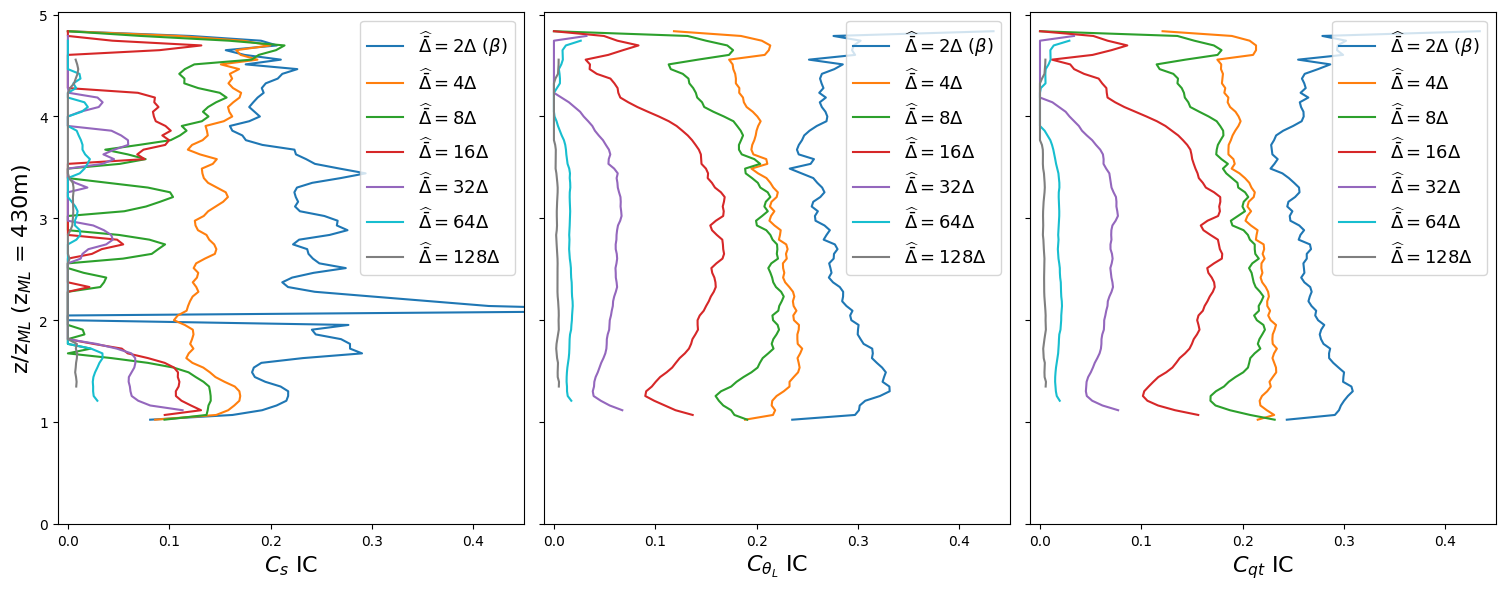

In [98]:
p = 2

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'IC', plot_dir_BOMEX, set_x_axis = [-0.01, 0.45])

for all Delta profs, min is =  -0.01 max is = 0.2


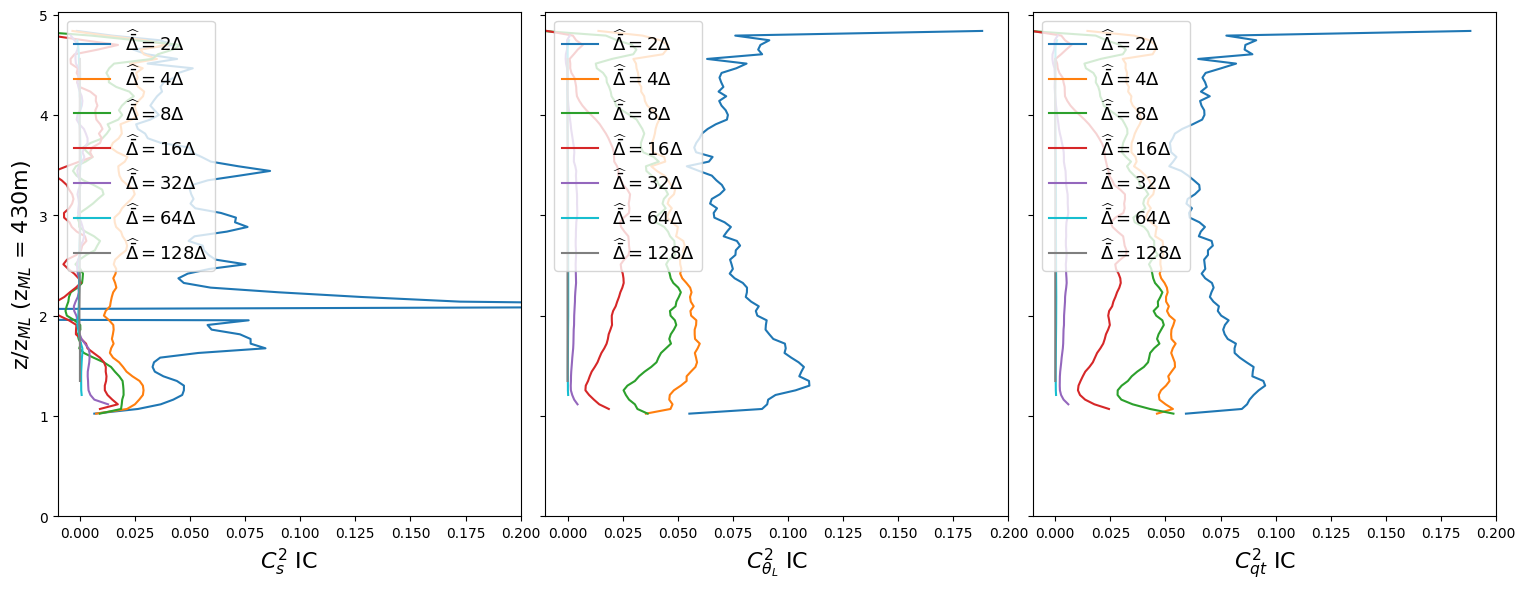

In [99]:
p = 2

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'IC', plot_dir_BOMEX, C_type = 'C_sq', IC_label=True, set_x_axis = [-0.01, 0.2])

for all Delta profs, min is =  -0.08 max is = 0.1


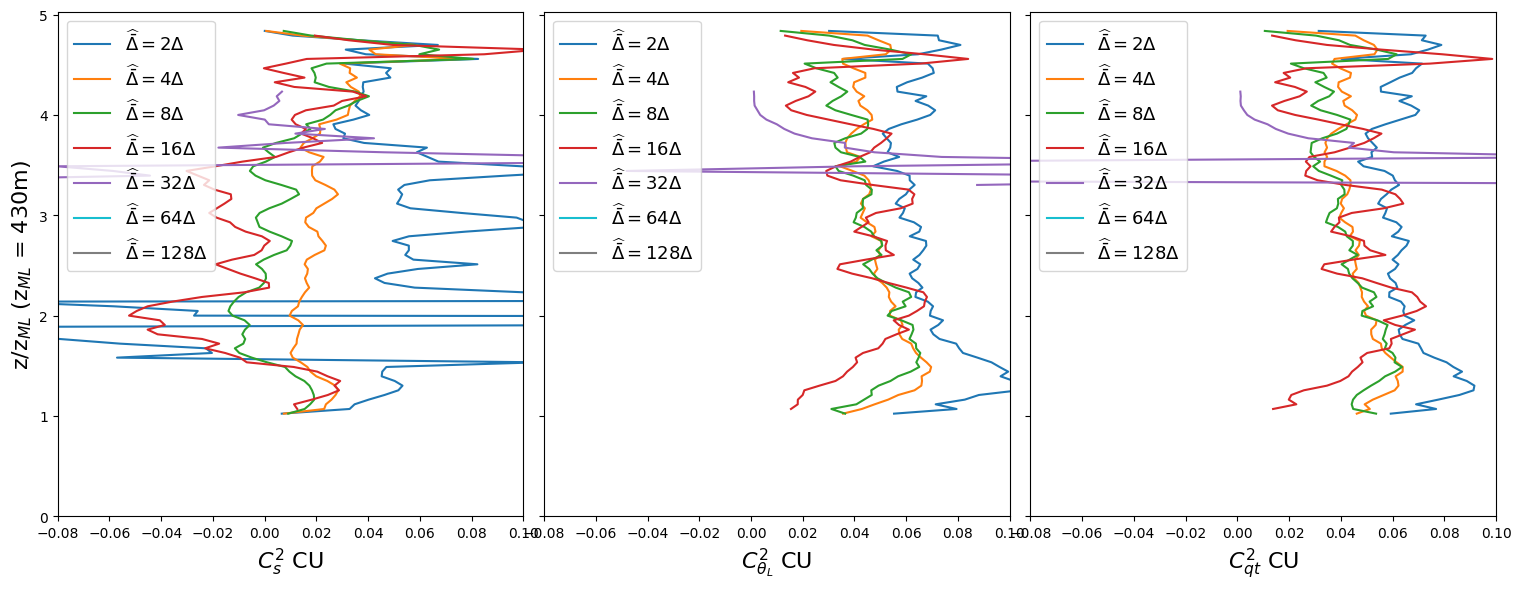

In [100]:
p = 3

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'CU', plot_dir_BOMEX, C_type = 'C_sq', set_x_axis = [-0.08, 0.1], IC_label=True)

for all Delta profs, min is =  -0.01 max is = 0.3


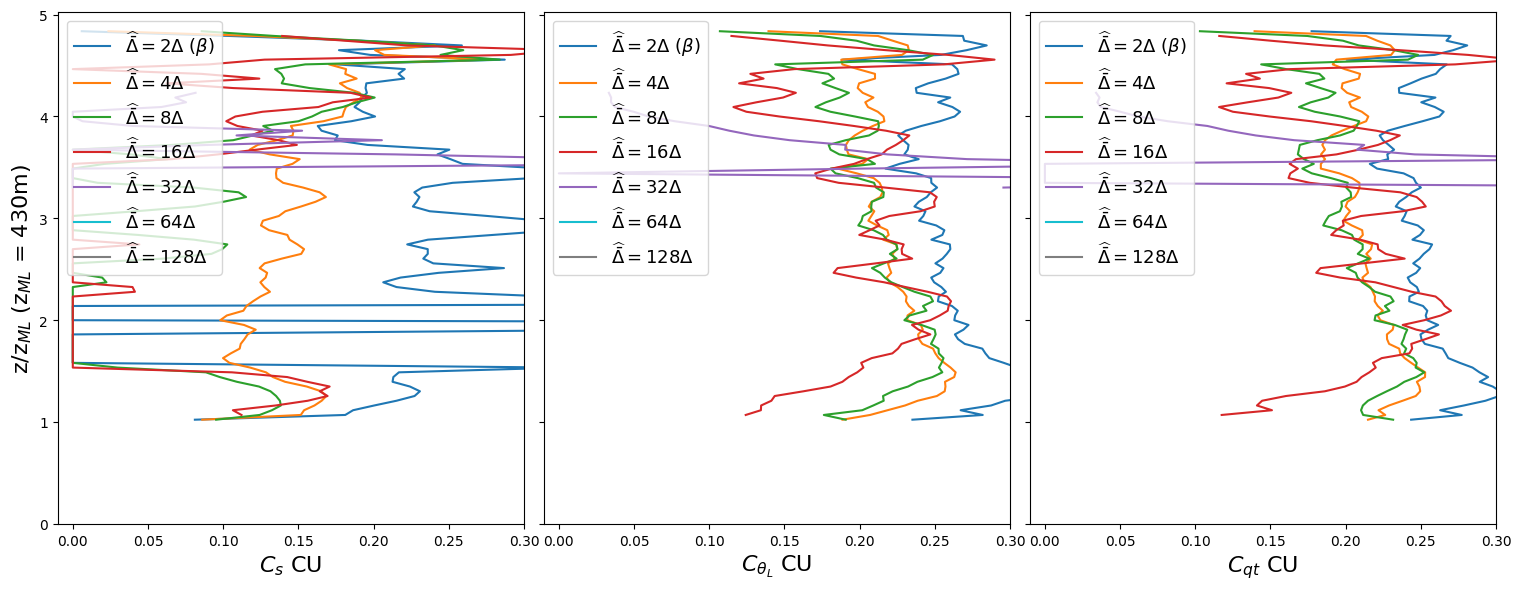

In [101]:
p = 3

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'CU', plot_dir_BOMEX, C_type = 'C', set_x_axis = [-0.01, 0.3], IC_label=True)

for all Delta profs, min is =  -0.08 max is = 0.1


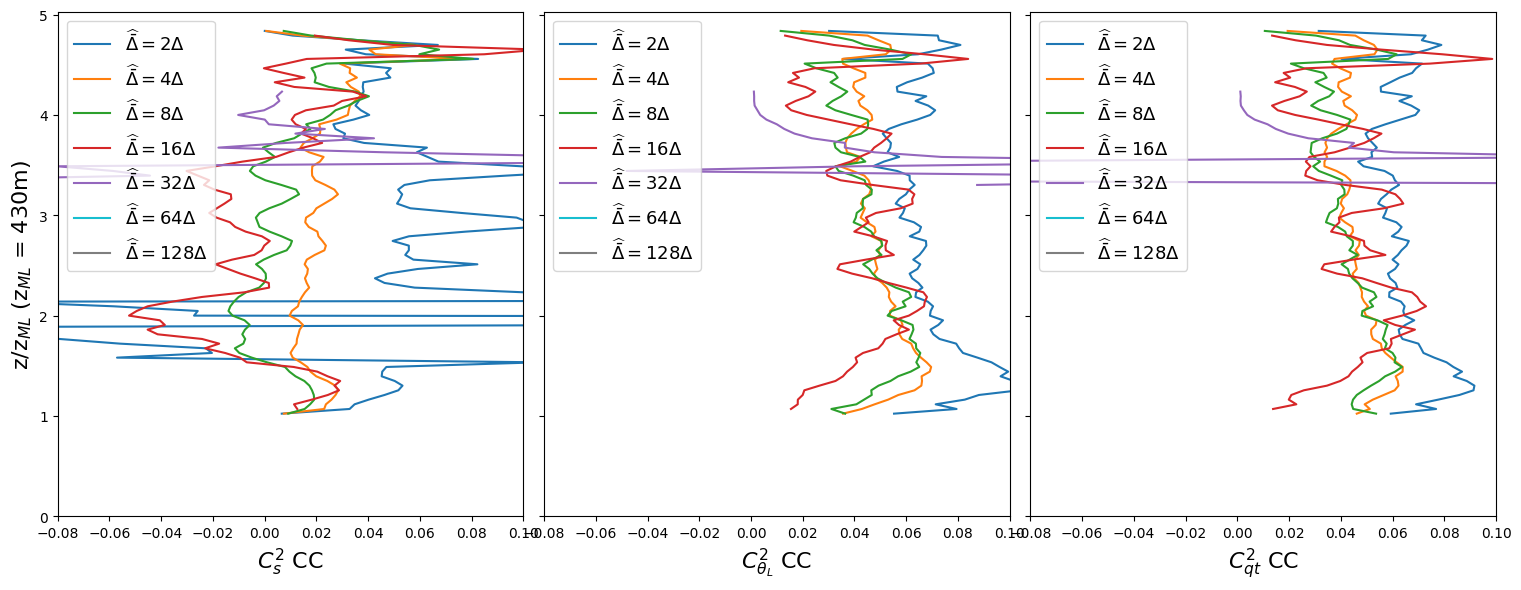

In [102]:
p = 4

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'CC', plot_dir_BOMEX, C_type = 'C_sq', set_x_axis = [-0.08, 0.1], IC_label=True)

for all Delta profs, min is =  -0.01 max is = 0.35


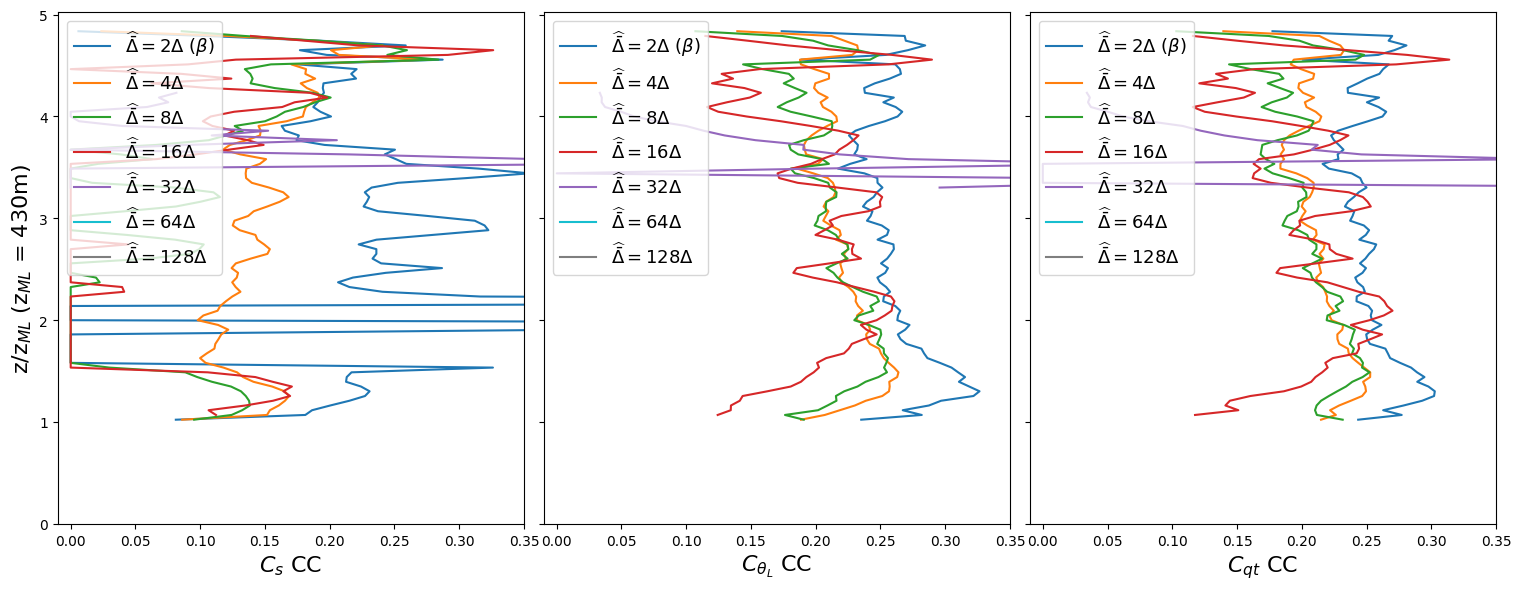

In [103]:
p = 4

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'CC', plot_dir_BOMEX, C_type = 'C', set_x_axis = [-0.01, 0.35], IC_label=True)

In [104]:
Pr = C_sq_BOMEX_0[0,...]/C_sq_BOMEX_0[1,...]
Sc = C_sq_BOMEX_0[0,...]/C_sq_BOMEX_0[2,...]

print(np.shape(Pr))

(5, 6, 151)


In [105]:
# Pr[Pr > 2.95] = np.nan
# Pr[Pr < -0.45] = np.nan
#
# Sc[Sc > 2.95] = np.nan
# Sc[Sc < -0.45] = np.nan
#
# Pr = ma.masked_invalid(Pr)
# Sc = ma.masked_invalid(Sc)

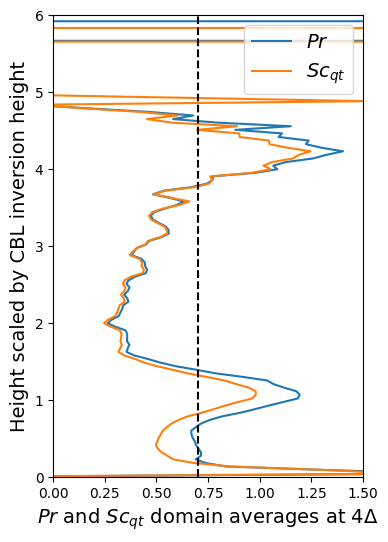

In [107]:
p = 0
d = 0

Pr_set = Pr[p, d,...]
Sc_set = Sc[p, d,...]

plt.figure(figsize=(4, 6))
plt.plot(Pr_set, z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc_set, z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$Pr$ and $Sc_{qt}$' + f' domain averages at {set_labels[d]}', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(0, 1.5)

plt.axvline(0.7, bottom0, top0, color='k', linestyle='dashed')

plt.ylim(0, 6)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_{partit[p]}_{deltas[d]}.pdf', bbox_inches='tight')

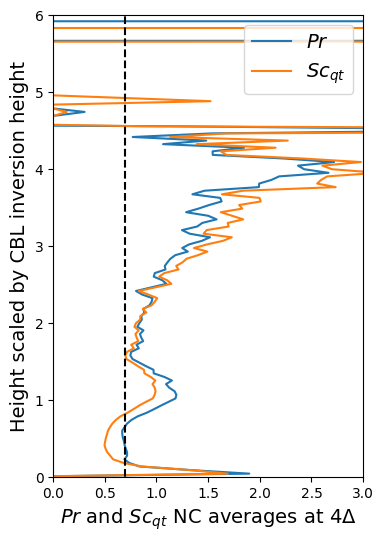

In [64]:
p = 1
d = 0

Pr_set = Pr[p, d,...]
Sc_set = Sc[p, d,...]

plt.figure(figsize=(4, 6))
plt.plot(Pr_set, z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc_set, z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$Pr$ and $Sc_{qt}$' + f' {partit[p]} averages at {set_labels[d]}', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(0, 3)

plt.axvline(0.7, bottom0, top0, color='k', linestyle='dashed')

plt.ylim(0, 6)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_{partit[p]}_{deltas[d]}.png', bbox_inches='tight')

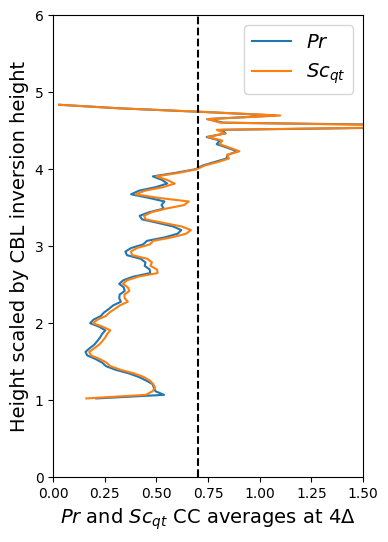

In [69]:
p = 4
d = 0

Pr_set = Pr[p, d, ...]
Sc_set = Sc[p, d, ...]

plt.figure(figsize=(4, 6))
plt.plot(Pr_set, z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc_set, z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$Pr$ and $Sc_{qt}$' + f' {partit[p]} averages at {set_labels[d]}', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(0, 1.5)

plt.axvline(0.7, 0, top0, color='k', linestyle='dashed')

plt.ylim(0, 6)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_{partit[p]}_{deltas[d]}.png', bbox_inches='tight')

In [73]:
Cs_sq = np.load(path+f'Cs_sq_cond_32400.npy')[0]
np.shape(Cs_sq)

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/si818415/Documents/code/LES_analysis/data/Cs_sq_cond_32400.npy'

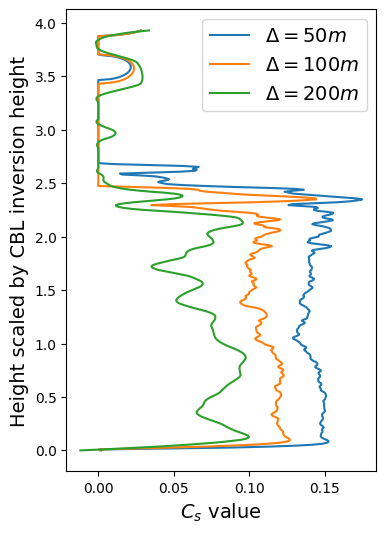

In [94]:
plt.figure(figsize=(4,6))
plt.plot(get_Cs(Cs_sq)[1,:], z/z_i, label='$\\Delta = 50m$')
plt.plot(get_Cs(Cs_sq)[2,:], z/z_i, label='$\\Delta = 100m$')
plt.plot(sc.savgol_filter(get_Cs(Cs_sq)[3,:], 21, 3), z/z_i, label='$\\Delta = 200m$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C_s$ value', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig('ARM_C_50_100_200.pdf', bbox_inches='tight')

In [87]:
def l_mix_MONC(Delta, Cs, z_in, k=0.4):
    l_mix = np.sqrt(1 / ((1 / (Cs * Cs * Delta * Delta)) + (1 / (k * k * z_in * z_in))))

    return l_mix

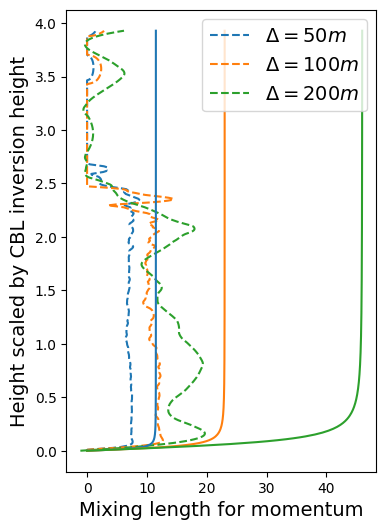

In [103]:
plt.figure(figsize=(4,6))
plt.plot(50*get_Cs(Cs_sq)[1,:], z/z_i, '--', label='$\\Delta = 50m$')
plt.plot(100*get_Cs(Cs_sq)[2,:], z/z_i, '--', label='$\\Delta = 100m$')
plt.plot(sc.savgol_filter(200*get_Cs(Cs_sq)[3,:], 51, 3), z/z_i, '--', label='$\\Delta = 200m$')
plt.plot(l_mix_MONC(50, 0.23, z), z/z_i, color='tab:blue')
plt.plot(l_mix_MONC(100, 0.23, z), z/z_i, color='tab:orange')
plt.plot(l_mix_MONC(200, 0.23, z), z/z_i, color='tab:green')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('Mixing length for momentum', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig('ARM_lmix_50_100_200.pdf', bbox_inches='tight')